# Transformer回归分析

## $\S1$ Configuration & Data Preparation

In [13]:
# Configuration
## Loading Packages
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import shap

## Random Seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
SEED  = 42
set_seed(SEED)

## Calculate Device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

## Data Path
DATA_PATH = "./Raw_Data_5.xlsx"
Dependent_Variable = "USD_index_Close"

## Train and Test Ratio
TRAIN_RATIO = 0.60
VAL_RATIO   = 0.20
TEST_RATIO  = 1 - TRAIN_RATIO - VAL_RATIO

## Hyper Parameters
MULTIPLE_Y=1000
N_EPOCHS = 100
PATIENCE   = 10
WEIGHT_DECAY = 1e-5

LOOKBACK_LIST   = [10, 20, 30]
BATCH_SIZE_LIST = [32, 64, 128]
D_MODEL_LIST    = [16, 32]
NHEAD_LIST      = [2, 4]
NUM_LAYERS_LIST = [1, 2]
DIM_FEEDFORWARD_LIST = [128, 256]
DROPOUT_LIST    = [0.2, 0.3]
LR_LIST         = [1e-4, 5e-5, 1e-5]

Device: cuda


In [14]:
# Data Preparation
## Loading Data
Data = pd.read_excel(DATA_PATH, index_col="日期")
print("Data Size:", Data.shape)
print("Columns:", Data.columns)

## Extract Values
X = Data.drop(columns=[Dependent_Variable]).values.astype(np.float32)
y = Data[Dependent_Variable].values.astype(np.float32) * MULTIPLE_Y

## Train, Valid and Test Split
N = len(X)
n_train = int(N * TRAIN_RATIO)
n_val   = int(N * VAL_RATIO)
n_test  = N - n_train - n_val
print(f"训练集: {n_train}, 验证集: {n_val}, 测试集: {n_test}")

X_train = X[:n_train]
y_train = y[:n_train]
X_val   = X[n_train:n_train + n_val]
y_val   = y[n_train:n_train + n_val]
X_test  = X[n_train + n_val:]
y_test  = y[n_train + n_val:]

## Extract Dates
dates = Data.index.to_series()
dates_train = dates[:n_train]
dates_val   = dates[n_train:n_train + n_val]
dates_test  = dates[n_train + n_val:]

Data Size: (3456, 36)
Columns: Index(['USD_index_Close', 'USD_EUR_Open', 'USD_JPY_Open', 'USD_GBP_Open',
       'USD_CNY_Open', 'GOLD_Open', 'WTI_Open', 'US_10Y_Open', 'CN_10Y_Open',
       'UK_10Y_Open', 'JP_10Y_Open', 'GER_10Y_Open', 'VIX_Open',
       'US_index_Open', 'CN_index_Open', 'UK_index_Open', 'JP_index_Open',
       'GER_index_Open', 'US_10Y-CN_10Y_Open', 'US_10Y-GER_10Y_Open',
       'US_10Y-UK_10Y_Open', 'US_10Y-JP_10Y_Open', 'CN_10Y-GER_10Y_Open',
       'CN_10Y-UK_10Y_Open', 'CN_10Y-JP_10Y_Open', 'GER_10Y-UK_10Y_Open',
       'GER_10Y-JP_10Y_Open', 'UK_10Y-JP_10Y_Open', 'VIX_Delta',
       'USD_index_Close_Lag1', 'USD_index_Close_Lag4', 'USD_index_Close_Lag7',
       'USD_index_Close_Lag14', 'USD_index_Close_Std3', 'USD_index_Close_Std7',
       'USD_index_Close_Std14'],
      dtype='object')
训练集: 2073, 验证集: 691, 测试集: 692


In [15]:
### Data Scale
#### We will perform sacle dring Model selection and Final training


### Constructing Data Window
def create_sequences(X, y, seq_len):
    """
    X: (n_samples, n_features)
    y: (n_samples,)
    Return:
        X_seq: (N, seq_len, n_features)
        y_seq: (N,)
    """
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i+seq_len])
        y_seq.append(y[i+seq_len])
    X_seq = np.stack(X_seq).astype(np.float32)
    y_seq = np.array(y_seq, dtype=np.float32)
    return X_seq, y_seq

### Construct Dataset
class FXDataset(Dataset):
    def __init__(self, X_seq, y_seq):
        self.X = torch.from_numpy(X_seq).float()
        self.y = torch.from_numpy(y_seq).float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def make_dataloaders(X_train_seq, y_train_seq,
                     X_val_seq=None,   y_val_seq=None,
                     X_test_seq=None,  y_test_seq=None,
                     batch_size=64):
    train_dataset = FXDataset(X_train_seq, y_train_seq)
    train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_loader = None
    test_loader = None

    if X_val_seq is not None and y_val_seq is not None:
        val_dataset  = FXDataset(X_val_seq, y_val_seq)
        val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    if X_test_seq is not None and y_test_seq is not None:
        test_dataset = FXDataset(X_test_seq, y_test_seq)
        test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

## $\S2$ Model Selection, Training & Predicting

In [16]:
# Model Definition
## Positional Encoding
class PositionalEncoding(nn.Module):
    """
    位置编码 (batch_first 版本)
    输入: (batch, seq_len, d_model)
    """
    def __init__(self, d_model, max_len=5000, dropout=0.0):
        super().__init__()
        pe = torch.zeros(max_len, d_model)                                                          # (max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()                                    # (max_len, 1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))    # (d_model/2,)
        pe[:, 0::2] = torch.sin(position * div_term)    # 偶数维
        pe[:, 1::2] = torch.cos(position * div_term)    # 奇数维
        pe = pe.unsqueeze(0)                            # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        """
        x: (batch, seq_len, d_model)
        """
        seq_len = x.size(1)
        x = x + self.pe[:, :seq_len]
        return x
    


class TransformerRegressor(nn.Module):
    """
    输入: (batch, seq_len, input_size)
    输出: (batch, 1)
    """
    def __init__(self,
                 input_size,
                 d_model=64,
                 nhead=4,
                 num_layers=2,
                 dim_feedforward=128,
                 dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True  # 保持 (batch, seq_len, d_model)
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(d_model, 1)

    def forward(self, x):
        """
        x: (batch, seq_len, input_size)
        """
        # 1) 映射到 d_model 维
        x = self.input_proj(x)       # (batch, seq_len, d_model)
        # 2) 加位置编码
        x = self.pos_encoder(x)      # (batch, seq_len, d_model)
        # 3) 过 Transformer Encoder
        enc_out = self.encoder(x)    # (batch, seq_len, d_model)
        # 4) 时间维池化：这里用平均池化（也可以用 enc_out[:, -1, :] 取最后一步）
        pooled = enc_out.mean(dim=1)  # (batch, d_model)
        # 5) 回归输出
        out = self.fc_out(pooled)     # (batch, 1)
        return out

In [17]:
# Model Training
## Training in Model Selection
def train_model(model,
                train_loader,
                val_loader=None,
                n_epochs=50,
                lr=1e-3,
                weight_decay=1e-5,
                patience=8,
                device=DEVICE):

    model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_losses = []
    val_losses   = []

    best_val_loss   = float("inf")
    best_state_dict = None
    wait = 0

    for epoch in range(1, n_epochs + 1):
        # ---------- Training ----------
        model.train()
        train_loss_sum = 0.0
        n_train_samples = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)                   # (batch, seq_len, input_size)
            y_batch = y_batch.to(device).view(-1, 1)       # (batch, 1)

            optimizer.zero_grad()
            y_pred = model(X_batch)                        # (batch, 1)
            loss   = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()

            train_loss_sum   += loss.item() * len(X_batch)
            n_train_samples  += len(X_batch)

        train_loss = train_loss_sum / n_train_samples
        train_losses.append(train_loss)

        # ---------- Validation ----------
        if val_loader is None:
            print(f"Epoch {epoch:03d} | train_loss={train_loss:.6f}")
            continue

        model.eval()
        val_loss_sum = 0.0
        n_val_samples = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device).view(-1, 1)
                y_pred  = model(X_batch)
                loss    = criterion(y_pred, y_batch)

                val_loss_sum   += loss.item() * len(X_batch)
                n_val_samples  += len(X_batch)

        val_loss = val_loss_sum / n_val_samples
        val_losses.append(val_loss)

        print(f"Epoch {epoch:03d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

        # Early Stopping
        if val_loss < best_val_loss - 1e-8:
            best_val_loss   = val_loss
            best_state_dict = model.state_dict()
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {epoch}, best_val_loss={best_val_loss:.6f}")
                break

    # 恢复最优参数
    if val_loader is not None and best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return model, train_losses, val_losses, best_val_loss

## Training in Model Prediction
def train_model_with_eval(model,
                          train_loader,
                          eval_loader,
                          n_epochs=50,
                          lr=1e-3,
                          weight_decay=1e-5,
                          device=DEVICE):
    """
    与 train_model 的区别：
    - 不做 early stopping，每个 epoch 都完整训练一遍
    - 每个 epoch 都在 eval_loader 上跑一次评估，记录 eval_loss（这里就是 test loss）
    - 返回：模型、每个 epoch 的 train_losses 和 eval_losses
    """
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_losses = []
    eval_losses  = []

    for epoch in range(1, n_epochs + 1):
        # --------- Training ---------
        model.train()
        train_loss_sum = 0.0
        n_train = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).view(-1, 1)

            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * len(X_batch)
            n_train += len(X_batch)

        train_loss = train_loss_sum / n_train
        train_losses.append(train_loss)

        # --------- Eval (这里用 test_loader，当作 eval_loader) ---------
        model.eval()
        eval_loss_sum = 0.0
        n_eval = 0

        with torch.no_grad():
            for X_batch, y_batch in eval_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device).view(-1, 1)
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)

                eval_loss_sum += loss.item() * len(X_batch)
                n_eval += len(X_batch)

        eval_loss = eval_loss_sum / n_eval
        eval_losses.append(eval_loss)

        print(f"Epoch {epoch:03d} | train_loss={train_loss:.6f} | eval_loss={eval_loss:.6f}")

    # 不做 early stopping，也不回滚最优参数，直接返回最后一轮的模型
    return model, train_losses, eval_losses


In [14]:
# Model Selection
input_size = X_train.shape[1]
print("Input feature dim:", input_size)

best_config = None
best_val_rmse_overall = float("inf")

for lookback in LOOKBACK_LIST:
    print("=" * 80)
    print(f"Trying lookback = {lookback}")

    # 1) 针对给定 lookback，对 Train / Val 做 scaler
    scaler_X_cv = StandardScaler()
    X_train_scaled_cv = scaler_X_cv.fit_transform(X_train)
    X_val_scaled_cv   = scaler_X_cv.transform(X_val)

    y_train_cv = y_train.copy()
    y_val_cv   = y_val.copy()

    # 2) 构造序列
    X_train_seq_cv, y_train_seq_cv = create_sequences(X_train_scaled_cv, y_train_cv, lookback)
    X_val_seq_cv,   y_val_seq_cv   = create_sequences(X_val_scaled_cv,   y_val_cv,   lookback)

    print("Train seq shape:", X_train_seq_cv.shape, "Val seq shape:", X_val_seq_cv.shape)

    count = 0
    for batch_size in BATCH_SIZE_LIST:
        for d_model in D_MODEL_LIST:
            for nhead in NHEAD_LIST:
                # 约束：nhead 必须整除 d_model
                if d_model % nhead != 0:
                    continue
                for num_layers in NUM_LAYERS_LIST:
                    for dim_ff in DIM_FEEDFORWARD_LIST:
                        for dropout in DROPOUT_LIST:
                            for lr in LR_LIST:
                                config = {
                                    "lookback": lookback,
                                    "batch_size": batch_size,
                                    "d_model": d_model,
                                    "nhead": nhead,
                                    "num_layers": num_layers,
                                    "dim_feedforward": dim_ff,
                                    "dropout": dropout,
                                    "lr": lr
                                }
                                count += 1
                                print(f"loop number:{count}")
                                print("\nConfig:", config)

                                train_loader_cv, val_loader_cv, _ = make_dataloaders(
                                    X_train_seq_cv, y_train_seq_cv,
                                    X_val_seq_cv,   y_val_seq_cv,
                                    None, None,
                                    batch_size=batch_size
                                )

                                model_cv = TransformerRegressor(
                                    input_size=input_size,
                                    d_model=d_model,
                                    nhead=nhead,
                                    num_layers=num_layers,
                                    dim_feedforward=dim_ff,
                                    dropout=dropout
                                )

                                model_cv, train_losses_cv, val_losses_cv, best_val_loss_cv = train_model(
                                    model_cv,
                                    train_loader_cv,
                                    val_loader_cv,
                                    n_epochs=N_EPOCHS,
                                    lr=lr,
                                    weight_decay=WEIGHT_DECAY,
                                    patience=PATIENCE,
                                    device=DEVICE
                                )

                                # 用当前最优模型，在验证集上计算 RMSE（基于当前尺度的 y）
                                model_cv.eval()
                                y_val_true_list = []
                                y_val_pred_list = []
                                with torch.no_grad():
                                    for X_batch, y_batch in val_loader_cv:
                                        X_batch = X_batch.to(DEVICE)
                                        y_batch = y_batch.to(DEVICE).view(-1, 1)
                                        y_pred  = model_cv(X_batch)
                                        y_val_true_list.append(y_batch.cpu().numpy())
                                        y_val_pred_list.append(y_pred.cpu().numpy())

                                y_val_true_scaled = np.concatenate(y_val_true_list).ravel()
                                y_val_pred_scaled = np.concatenate(y_val_pred_list).ravel()

                                val_rmse = root_mean_squared_error(y_val_true_scaled, y_val_pred_scaled)
                                print(f"Validation RMSE: {val_rmse:.6f}")

                                if val_rmse < best_val_rmse_overall:
                                    best_val_rmse_overall = val_rmse
                                    best_config = config.copy()

print("\nBest config (on Train/Val):", best_config)
print("Best validation RMSE (scaled y):", best_val_rmse_overall)

Input feature dim: 35
Trying lookback = 10
Train seq shape: (2063, 10, 35) Val seq shape: (681, 10, 35)
loop number:1

Config: {'lookback': 10, 'batch_size': 32, 'd_model': 16, 'nhead': 2, 'num_layers': 1, 'dim_feedforward': 128, 'dropout': 0.2, 'lr': 0.0001}
Epoch 001 | train_loss=27.394078 | val_loss=14.616353
Epoch 002 | train_loss=27.362583 | val_loss=14.619372
Epoch 003 | train_loss=27.324818 | val_loss=14.623044
Epoch 004 | train_loss=27.334705 | val_loss=14.624903
Epoch 005 | train_loss=27.319461 | val_loss=14.627487
Epoch 006 | train_loss=27.310709 | val_loss=14.632842
Epoch 007 | train_loss=27.301363 | val_loss=14.630119
Epoch 008 | train_loss=27.315426 | val_loss=14.637049
Epoch 009 | train_loss=27.309378 | val_loss=14.633802
Epoch 010 | train_loss=27.288508 | val_loss=14.635665
Epoch 011 | train_loss=27.287591 | val_loss=14.637938
Early stopping at epoch 11, best_val_loss=14.616353
Validation RMSE: 3.825956
loop number:2

Config: {'lookback': 10, 'batch_size': 32, 'd_model':

In [ ]:
# best_config = {
#     "lookback":20,
#     "batch_size":64,
#     "d_model":16,
#     "nhead":2,
#     "num_layers":1,
#     "dim_feedforward":256,
#     "dropout":0.2,
#     "lr":1e-5
# }

# Final Training & Predicting
print("\n===== Final Training with Best Config on Train+Val, then Evaluate on Test =====")
print("Best config:", best_config)

# 1) 合并 Train + Val
X_trainval = np.concatenate([X_train, X_val], axis=0)
y_trainval = np.concatenate([y_train, y_val], axis=0)

# 2) 使用 Train+Val 拟合 scaler（只对 X）
scaler_X_final = StandardScaler()
X_trainval_scaled = scaler_X_final.fit_transform(X_trainval)
X_test_scaled     = scaler_X_final.transform(X_test)
y_trainval_final = y_trainval.copy()
y_test_final     = y_test.copy()

# 3) 构造 TrainVal / Test 序列
final_lookback = best_config["lookback"]
X_trainval_seq, y_trainval_seq = create_sequences(X_trainval_scaled, y_trainval_final, final_lookback)
X_test_seq,     y_test_seq     = create_sequences(X_test_scaled,     y_test_final,     final_lookback)
print("TrainVal seq shape:", X_trainval_seq.shape, "Test seq shape:", X_test_seq.shape)

# 4) DataLoaders
final_batch_size = best_config["batch_size"]
train_loader_final, _, test_loader_final = make_dataloaders(
    X_trainval_seq, y_trainval_seq,
    None, None,
    X_test_seq, y_test_seq,
    batch_size=final_batch_size
)

# 5) 构造最终 Transformer 模型
final_model = TransformerRegressor(
    input_size = X_train.shape[1],
    d_model    = best_config["d_model"],
    nhead      = best_config["nhead"],
    num_layers = best_config["num_layers"],
    dim_feedforward = best_config["dim_feedforward"],
    dropout    = best_config["dropout"]
)

# 6) 在 Train+Val 上训练，同时每个 epoch 在 Test 上评估一次（仅用于画 loss 曲线）
final_model, train_losses_final, test_losses_final = train_model_with_eval(
    final_model,
    train_loader_final,
    eval_loader=test_loader_final,   # 这里就是 test loss
    n_epochs=N_EPOCHS,
    lr=best_config["lr"],
    weight_decay=WEIGHT_DECAY,
    device=DEVICE
)


# 7) 在 Test 上评估
final_model.eval()
y_true_list = []
y_pred_list = []
with torch.no_grad():
    for X_batch, y_batch in test_loader_final:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE).view(-1, 1)
        y_pred  = final_model(X_batch)

        y_true_list.append(y_batch.cpu().numpy())
        y_pred_list.append(y_pred.cpu().numpy())

y_true_scaled = np.concatenate(y_true_list).ravel()
y_pred_scaled = np.concatenate(y_pred_list).ravel()

## 还原label
y_true = y_true_scaled / MULTIPLE_Y
y_pred = y_pred_scaled / MULTIPLE_Y


===== Final Training with Best Config on Train+Val, then Evaluate on Test =====
Best config: {'lookback': 20, 'batch_size': 64, 'd_model': 16, 'nhead': 2, 'num_layers': 1, 'dim_feedforward': 256, 'dropout': 0.2, 'lr': 1e-05}
TrainVal seq shape: (2744, 20, 35) Test seq shape: (672, 20, 35)
Epoch 001 | train_loss=24.295566 | eval_loss=21.373731
Epoch 002 | train_loss=24.275095 | eval_loss=21.364857
Epoch 003 | train_loss=24.257967 | eval_loss=21.356501
Epoch 004 | train_loss=24.248502 | eval_loss=21.351168
Epoch 005 | train_loss=24.237896 | eval_loss=21.345590
Epoch 006 | train_loss=24.227096 | eval_loss=21.339100
Epoch 007 | train_loss=24.214518 | eval_loss=21.334740
Epoch 008 | train_loss=24.209067 | eval_loss=21.331493
Epoch 009 | train_loss=24.191026 | eval_loss=21.328679
Epoch 010 | train_loss=24.194778 | eval_loss=21.326856
Epoch 011 | train_loss=24.192129 | eval_loss=21.324821
Epoch 012 | train_loss=24.182754 | eval_loss=21.323673
Epoch 013 | train_loss=24.181029 | eval_loss=21.3

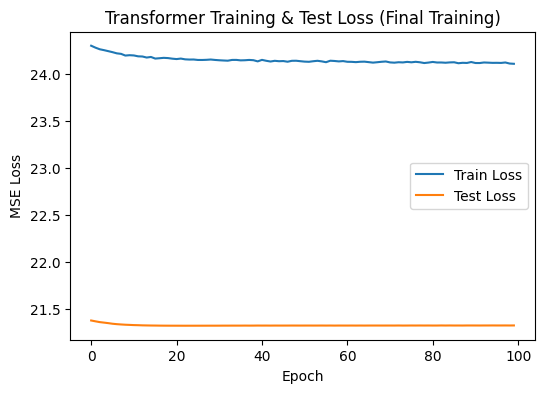

len(dates_test_seq): 672
len(y_true): 672 len(y_pred): 672


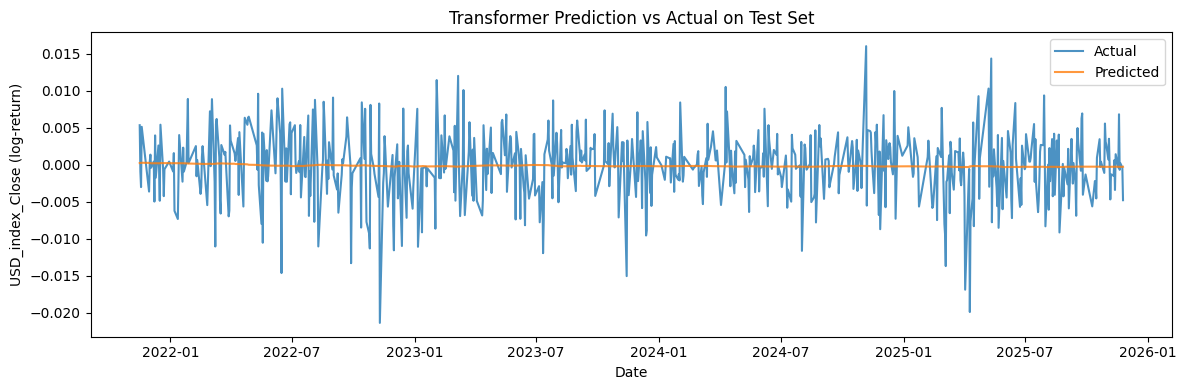

In [20]:
## Training Plotting
plt.figure(figsize=(6, 4))
plt.plot(train_losses_final, label="Train Loss")
plt.plot(test_losses_final,  label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Transformer Training & Test Loss (Final Training)")
plt.legend()
plt.show()

# Test 段的日期长度是 n_test，对应我们创建序列时丢掉了前 lookback 个
# 所以 y_true / y_pred 对应的是：
final_lookback = best_config["lookback"]
dates_test_seq = dates_test[final_lookback:]   # 长度应该与 y_true 一致
print("len(dates_test_seq):", len(dates_test_seq))
print("len(y_true):", len(y_true), "len(y_pred):", len(y_pred))

## Prediction Plotting
min_len = min(len(dates_test_seq), len(y_true), len(y_pred))
dates_plot = dates_test_seq[:min_len]
y_true_plot = y_true[:min_len]
y_pred_plot = y_pred[:min_len]

plt.figure(figsize=(12, 4))
plt.plot(dates_plot, y_true_plot, label="Actual", alpha=0.8)
plt.plot(dates_plot, y_pred_plot, label="Predicted", alpha=0.8)
plt.title("Transformer Prediction vs Actual on Test Set")
plt.xlabel("Date")
plt.ylabel(Dependent_Variable + " (log-return)")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
## Evaluation
rmse = root_mean_squared_error(y_true, y_pred)
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)

print("\n===== Test Performance (Transformer, Train+Val refit) =====")
print(f"RMSE: {rmse:.6f}")
print(f"MAE : {mae:.6f}")
print(f"R^2 : {r2:.6f}")

### 方向准确率（涨跌方向）
sign_true = np.sign(np.diff(y_true))
sign_pred = np.sign(np.diff(y_pred))
if len(sign_true) == len(sign_pred) and len(sign_true) > 0:
    direction_acc = (sign_true == sign_pred).mean()
    print(f"Direction Accuracy (sign of change): {direction_acc:.4f}")


===== Test Performance (Transformer, Train+Val refit) =====
RMSE: 0.004617
MAE : 0.003487
R^2 : 0.001813
Direction Accuracy (sign of change): 0.5127
